<a href="https://colab.research.google.com/github/batoolrabia888-ctrl/Rabia-Batool/blob/main/sample_super_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [5]:
df = pd.read_csv('samplesuperstore.csv')
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [ ]:
#cities with highly lostes
conn = sqlite3.connect(':memory:')
df.to_sql('data',conn,index = False,if_exists = 'replace')
query = 'select City,Discount,Profit from data where Profit<0 order by City DESC limit 5'
highly_lostable_cities = pd.read_sql_query(query,conn)
print (highly_lostable_cities)

   City  Discount    Profit
0  Yuma       0.7  -35.8848
1  Yuma       0.7 -479.9880
2  York       0.3  -18.0882
3  York       0.7  -27.9312
4  York       0.2  -50.8704


<Axes: >

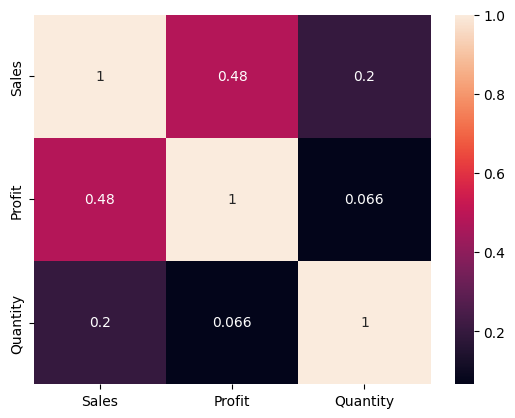

In [ ]:
# check corelation to identify business loss
corr_column = df[['Sales','Profit','Quantity']].corr()
sns.heatmap(data = corr_column,annot = True)

In [ ]:
# change data in month formate
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# 2. new colums for months and years
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# 3. check data types
print(df[['Order Date', 'Month', 'Year']].dtypes)

Order Date    datetime64[ns]
Month                float64
Year                 float64
dtype: object


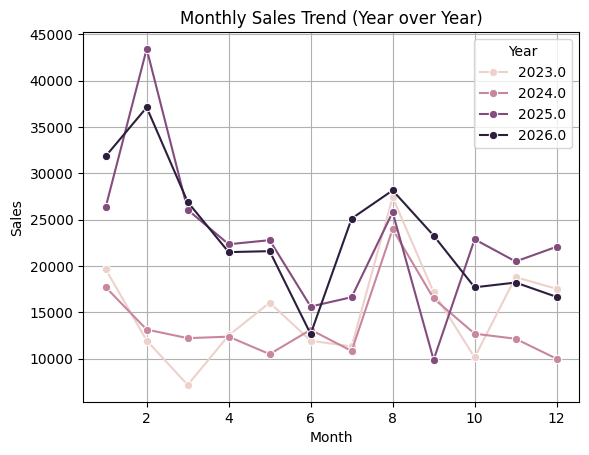

In [ ]:
# sum of sales according to moths and years
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

sns.lineplot(x='Month', y='Sales', hue='Year', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend (Year over Year)')
plt.grid(True)
plt.show()